## Visualizing Depth From EXR
To run this notebook you first have to generate the `toy_dataset` which can be generated by executing `make toy_dataset`

In [1]:
import OpenEXR
import numpy as np
import Imath
import array
import cv2
import matplotlib.pyplot as plt
import json

### EXR to numpy array
Thanks to [Tobias Weis](http://www.tobias-weis.de/groundtruth-data-for-computer-vision-with-blender/)

In [2]:
def exr2numpy(exr, maxvalue=1., normalize=True):
    """ converts 1-channel exr-data to 2D numpy arrays """
    file = OpenEXR.InputFile(exr)

    # Compute the size
    dw = file.header()['dataWindow']
    sz = (dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1)

    # Read the three color channels as 32-bit floats
    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)
    (R) = [array.array('f', file.channel(Chan, FLOAT)).tolist()
           for Chan in ("R")]

    # create numpy 2D-array
    img = np.zeros((sz[1], sz[0], 3), np.float64)

    # normalize
    data = np.array(R)
    data[data > maxvalue] = maxvalue

    if normalize:
        data /= np.max(data)

    img = np.array(data).reshape(img.shape[0], -1)

    return img

### Read the color image

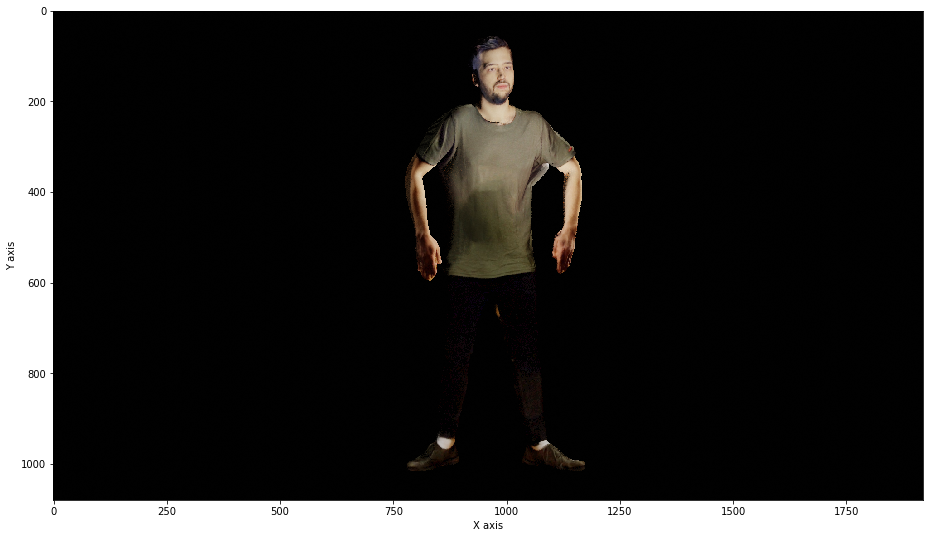

In [3]:
# The frame of the dataset we will use for visualization
FRAME_NUM = 5

# Create the figure
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

# Plot the color image
color = cv2.cvtColor(cv2.imread('../data/toy_dataset/color/Image{:0>4}.png'.format(FRAME_NUM)), cv2.COLOR_RGB2BGR)
ax.imshow(color)
plt.show()

### Read the depth EXR file
Depth values are in meters but in order to visualize them we normalize the range 0-5 meters

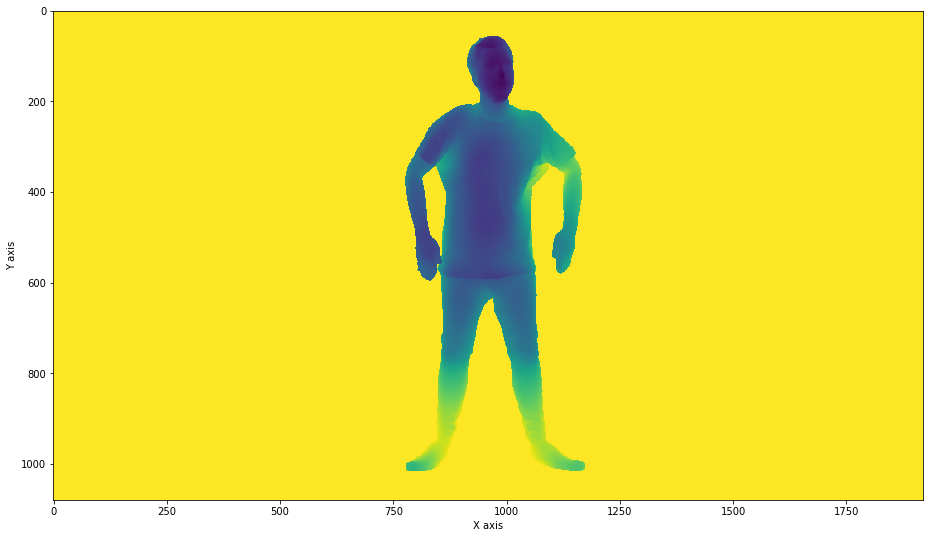

In [4]:
# Create the figure
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

# Draw the depth
depth_data = exr2numpy('../data/toy_dataset/depth/Image{:0>4}.exr'.format(FRAME_NUM), maxvalue=5, normalize=False)
ax.imshow(depth_data)
plt.show()